# **LangChain Neo4j**

---

## **기본 개요**

- **LangChain과 Neo4j 그래프 데이터베이스의 통합** 기능 제공
- Neo4j 데이터베이스와 LangChain을 함께 사용하여 **AI 기반 지식 그래프 애플리케이션** 구축
- **설치**: `pip install -U langchain-neo4j`
- **공식 문서**: [LangChain Neo4j Integration](https://python.langchain.com/docs/integrations/graphs/neo4j_cypher/)

- **📊 주요 활용 사례**
    - 📈 **지식 그래프 기반 RAG**: 복잡한 관계 정보를 활용한 검색 증강 생성
    - 🤖 **대화형 AI 시스템**: 문맥을 유지하는 챗봇 및 가상 어시스턴트
    - 🔍 **의미론적 검색**: 벡터 임베딩과 그래프 구조를 결합한 하이브리드 검색
    - 💡 **추천 시스템**: 관계 기반 개인화 추천 엔진

- **핵심 컴포넌트 소개**
    1. **Neo4jGraph**: 그래프 데이터베이스 연결 및 Cypher 쿼리 실행
    2. **Neo4jChatMessageHistory**: 대화 이력 그래프 저장
    3. **Neo4jVector**: 벡터 기반 의미론적 검색
    4. **GraphCypherQAChain**: 자연어-Cypher 변환 및 QA
    5. **LLMGraphTransformer***: 텍스트에서 지식 그래프 구축


## **1. Neo4jGraph**

- **Neo4jGraph** 클래스는 Neo4j Python 드라이버를 래핑하여 **간단한 인터페이스** 제공
- Neo4j 데이터베이스와의 상호 작용 및 기본적인 **Cypher 쿼리** 실행이 가능

In [1]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

# 환경 변수 로드
load_dotenv()

# 최신 Neo4jGraph 연결 
graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"), 
    username=os.getenv("NEO4J_USERNAME"), 
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE", "neo4j"),  # 명시적 데이터베이스 지정
    refresh_schema=True,  # 스키마 자동 갱신
    sanitize=True,  # 쿼리 검증 강화
    enhanced_schema=True  # 향상된 스키마 정보 제공
)

# 연결 상태 확인
try:
    result = graph.query("RETURN 'Neo4j 연결 성공!' as message, datetime() as timestamp")
    print(f"연결 결과: {result[0]}")
except Exception as e:
    print(f"연결 실패: {e}")

/Users/1113569/my-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


연결 결과: {'message': 'Neo4j 연결 성공!', 'timestamp': neo4j.time.DateTime(2025, 9, 30, 6, 43, 27, 744000000, tzinfo=<UTC>)}


## **2. Neo4jChatMessageHistory - 대화 이력 관리**

- **Neo4jChatMessageHistory**는 채팅 메시지를 **구조화된 그래프**로 저장
- **대화 패턴 분석**과 **컨텍스트 추적**이 가능


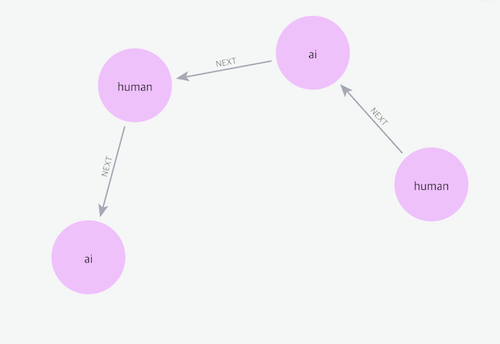

### **2.1 대화 이력 관리**

In [2]:
from langchain_neo4j import Neo4jChatMessageHistory
from datetime import datetime
import os

# 고급 설정으로 대화 이력 관리자 초기화
history = Neo4jChatMessageHistory( 
    session_id="session_001",
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database="neo4j",                    # 기본값: "neo4j"
    node_label="Session",                # 기본값: "Session" 
    window=2                             # 기본값: 2 (메시지 조회 시 가져올 메시지 쌍의 개수) -> window=3 이면 최근 6개 메시지 (사용자 3개 + AI 3개)를 조회
)


# 대화 이력 출력
history.messages


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: LAST_MESSAGE)} {position: line: 1, column: 23, offset: 22} for query: 'MATCH (s:`Session`)-[:LAST_MESSAGE]->(last_message) WHERE s.id = $session_id MATCH p=(last_message)<-[:NEXT*0..4]-() WITH p, length(p) AS length ORDER BY length DESC LIMIT 1 UNWIND reverse(nodes(p)) AS node RETURN {data:{content: node.content}, role:node.role} AS result'
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type i

[]

In [3]:
from langchain_core.messages import HumanMessage, AIMessage

# 대화 이력 추가
history.add_user_message(
    HumanMessage(
        content="hi",
        additional_kwargs={"language": "en"}
    )
)
history.add_ai_message(
    AIMessage(
        content="whats up?",
        additional_kwargs={"language": "en"}
    )
)

# 대화 이력 출력
history.messages

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={})]

In [4]:
# 대화 이력 추가 
history.add_user_message("Please tell me about yourself.")
history.add_ai_message("I am an AI assistant.")

# 대화 이력 출력
history.messages

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={})]

In [5]:
# 대화 이력 추가
history.add_user_message("What is your hobby?")
history.add_ai_message("I enjoy learning new things.")

# 대화 이력 출력
history.messages

[AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is your hobby?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I enjoy learning new things.', additional_kwargs={}, response_metadata={})]

### **2.2 대화 패턴 분석**

In [6]:
# 그래프 스키마 갱신
graph.refresh_schema()

In [7]:
# 세션 기반 분석 (마지막 메시지 추적)
session_analysis_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾는 쿼리
MATCH (s:Session {id: $session_id})
OPTIONAL MATCH (s)-[:LAST_MESSAGE]->(last:Message)
RETURN 
    s.id as session_id,
    last as last_message
"""

result = graph.query(session_analysis_query, {"session_id": history._session_id})
result

[{'session_id': 'session_001',
  'last_message': {'createdAt': neo4j.time.DateTime(2025, 9, 30, 6, 54, 36, 520000000, tzinfo=<UTC>),
   'role': 'ai',
   'content': 'I enjoy learning new things.'}}]

In [8]:
# 세션의 모든 메시지 가져오기 (연결된 체인 따라가기)
conversation_analysis_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾고, 
MATCH (s:Session {id: $session_id})-[:LAST_MESSAGE]->(last:Message)

// 마지막 메시지에서 시작하여 연결된 모든 메시지를 가져오는 쿼리 
MATCH path = (first:Message)-[:NEXT*0..]->(last)
WHERE NOT EXISTS(()-[:NEXT]->(first))

// 메시지 노드의 속성을 가져오는 쿼리
WITH nodes(path) as messages

// 메시지 노드를 UNWIND하여 각 메시지의 속성을 반환 (UNWIND: 배열 요소 하나씩 처리)
UNWIND messages as msg

RETURN 
    msg.content as content,
    msg.type as role
"""

result = graph.query(conversation_analysis_query, {"session_id": history._session_id})

result

[{'content': 'hi', 'role': None},
 {'content': 'whats up?', 'role': None},
 {'content': 'Please tell me about yourself.', 'role': None},
 {'content': 'I am an AI assistant.', 'role': None},
 {'content': 'What is your hobby?', 'role': None},
 {'content': 'I enjoy learning new things.', 'role': None}]

In [9]:
# 최근 3개 메시지만 출력
conversation_analysis_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾고, 
MATCH (s:Session {id: $session_id})-[:LAST_MESSAGE]->(last:Message)

// 마지막 메시지에서 시작하여 연결된 모든 메시지를 가져오는 쿼리 
MATCH path = (msg:Message)-[:NEXT*0..2]->(last)

// 메시지 노드의 속성을 가져오는 쿼리
WITH nodes(path) as messages

// 메시지 노드를 UNWIND하여 각 메시지의 속성을 반환
UNWIND messages as msg

// 중복 제거 및 정렬
RETURN DISTINCT
    msg.content as content,
    msg.type as role
"""

result = graph.query(conversation_analysis_query, {"session_id": history._session_id})

result

[{'content': 'I enjoy learning new things.', 'role': None},
 {'content': 'What is your hobby?', 'role': None},
 {'content': 'I am an AI assistant.', 'role': None}]

---

## **3. Neo4jVector - 벡터 검색**

**Neo4jVector**는 **하이브리드 검색**(벡터 + 그래프 관계)을 지원하여 더욱 정확한 의미론적 검색을 제공합니다.


In [10]:
# Article 노드를 조회하는 쿼리

query = "MATCH (n:Article) RETURN n"

articles = graph.query(query)

print(f"Article 노드 개수: {len(articles)}")

print(articles[0]) 

Article 노드 개수: 2
{'n': {'wordCount': 245, 'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 15), 'id': 'tech-001', 'source': '테크경제신문', 'category': 'technology', 'title': '엔비디아, AI 반도체 수요 급증으로 실적 고공행진', 'content': '엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특히 데이터센터용 GPU 판매가 크게 증가했으며, 젠슨 황 CEO는 AI 수요가 앞으로도 지속적으로 증가할 것으로 전망했다.'}}


### **3.1 기존 데이터를 활용한 벡터 스토어 구축**

In [11]:
from langchain_core.documents import Document

# 랭체인 문서로 변환 
docs = [
    Document(
        page_content=article["n"]["title"]+"\n\n"+article["n"]["content"],
        metadata={
            "author": article["n"]["author"],
            "publishDate": article["n"]["publishDate"],
            "source": article["n"]["source"],
        },
    )
    for article in articles
]

print(f"문서 개수: {len(docs)}")
print(docs[0].page_content)
print(docs[0].metadata)

문서 개수: 2
엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특히 데이터센터용 GPU 판매가 크게 증가했으며, 젠슨 황 CEO는 AI 수요가 앞으로도 지속적으로 증가할 것으로 전망했다.
{'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 15), 'source': '테크경제신문'}


In [12]:
from langchain_openai import OpenAIEmbeddings
from langchain_neo4j import Neo4jVector
import os

# 임베딩 모델 초기화
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",  # 최신 모델
    dimensions=1536,  # 차원 수 명시
    show_progress_bar=True  # 진행률 표시
)

# LangChain 도구 활용 - Neo4j 벡터 스토어 생성
db = Neo4jVector.from_documents(
    docs,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    index_name="article_embeddings",  # 인덱스 이름 명시
    node_label="Article",  # 벡터 노드 레이블
    text_node_property="content",  # 텍스트 속성명
    embedding_node_property="embedding",  # 임베딩 속성명
    create_id_index=False,  # ID 인덱스 생성 여부
)

100%|██████████| 1/1 [00:00<00:00,  1.66it/s]


### **3.2 다양한 검색 전략**

In [13]:
# 기본 유사도 검색
query = "AI 반도체에 대한 기사"

basic_results = db.similarity_search(query, k=2)

for doc in basic_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


문서 내용: 엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특...
메타데이터: {'author': '김기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 15)}
----------------------------------------
문서 내용: 삼성전자, 차세대 AI 반도체 개발 계획 발표

삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를...
메타데이터: {'author': '이기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 14)}
----------------------------------------


In [14]:
# 점수 포함 유사도 검색
scored_results = db.similarity_search_with_score(query, k=2)    

for doc, score in scored_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"점수: {score}")  # 점수 출력
    print("-" * 40)  # 구분선 출력

100%|██████████| 1/1 [00:00<00:00,  3.53it/s]

문서 내용: 엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특...
점수: 0.6793696880340576
----------------------------------------
문서 내용: 삼성전자, 차세대 AI 반도체 개발 계획 발표

삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를...
점수: 0.6749234199523926
----------------------------------------


In [15]:
# 메타데이터 필터링
filtered_results = db.similarity_search(
    query,  
    k=2,
    filter={"source": "테크경제신문"}  # 특정 출처로 필터링
)


for doc in filtered_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력


100%|██████████| 1/1 [00:00<00:00,  1.34it/s]


문서 내용: 엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특...
메타데이터: {'author': '김기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 15)}
----------------------------------------
문서 내용: 삼성전자, 차세대 AI 반도체 개발 계획 발표

삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를...
메타데이터: {'author': '이기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 14)}
----------------------------------------


In [16]:
# MMR (Maximal Marginal Relevance) 검색 - 다양성 고려
mmr_results = db.max_marginal_relevance_search(query, k=2, fetch_k=4)

for doc in mmr_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

100%|██████████| 1/1 [00:00<00:00,  3.32it/s]


문서 내용: 엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특...
메타데이터: {'author': '김기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 15)}
----------------------------------------
문서 내용: 삼성전자, 차세대 AI 반도체 개발 계획 발표

삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를...
메타데이터: {'author': '이기자', 'source': '테크경제신문', 'publishDate': neo4j.time.Date(2024, 3, 14)}
----------------------------------------


### **[실습]** 

- 다음 문서 목록을 이용하여 `Neo4jVector` 벡터 스토어를 구축하고, "LangChain Neo4j의 장점"과 유사한 문서를 검색하는 코드를 작성하세요. 
- OpenAI Embeddings 모델을 사용하고, 유사도 검색 결과를 문서 내용과 함께 출력하세요.

In [ ]:
from langchain.docstore.document import Document

documents = [
    Document(page_content="LangChain Neo4j는 Neo4j 그래프 데이터베이스와 LangChain을 통합합니다."),
    Document(page_content="Neo4j는 그래프 데이터 모델을 사용하는 NoSQL 데이터베이스입니다."),
    Document(page_content="LangChain은 LLM 기반 애플리케이션 개발을 위한 프레임워크입니다."),
    Document(page_content="Neo4jVector는 LangChain과 Neo4j를 연결하여 벡터 검색 기능을 제공합니다."),
    Document(page_content="LangChain Neo4j를 사용하면 지식 그래프 기반 RAG 시스템을 쉽게 구축할 수 있습니다."),
    Document(page_content="그래프 데이터베이스는 관계형 데이터베이스와 다르게 노드와 관계로 데이터를 표현합니다."),
    Document(page_content="RAG (Retrieval-Augmented Generation)는 검색 증강 생성 모델로, 외부 지식 기반을 활용합니다."),
    Document(page_content="Neo4j Cypher는 그래프 데이터베이스 쿼리 언어로, SQL과 유사하지만 그래프 구조에 최적화되어 있습니다."),
    Document(page_content="LangChain의 Agent 기능은 LLM이 도구와 상호작용하여 복잡한 태스크를 해결할 수 있게 합니다."),
    Document(page_content="지식 그래프는 정보를 구조화된 방식으로 표현하여 컨텍스트 기반 추론을 가능하게 합니다."),
    Document(page_content="벡터 임베딩은 텍스트를 수치적 벡터로 변환하여 의미적 유사성을 계산할 수 있게 합니다."),
    Document(page_content="하이브리드 검색은 키워드 기반 검색과 의미론적 검색을 결합하여 검색 품질을 향상시킵니다."),
    Document(page_content="Neo4j APOC는 그래프 데이터베이스 작업을 위한 확장 라이브러리입니다."),
    Document(page_content="LangChain 체인은 여러 LLM 컴포넌트를 연결하여 복잡한 워크플로우를 구성할 수 있습니다."),
    Document(page_content="그래프 RAG는 단순 벡터 검색보다 관계 정보를 활용하여 더 정확한 정보 검색이 가능합니다."),
    Document(page_content="Neo4j Bloom은 그래프 데이터를 시각화하고 탐색할 수 있는 도구입니다."),
    Document(page_content="프롬프트 엔지니어링은 LLM에게 효과적인 지시를 제공하는 기술입니다."),
    Document(page_content="LangChain 메모리 컴포넌트는 대화 이력을 관리하여 문맥을 유지합니다."),
    Document(page_content="Neo4j GraphQL은 그래프 데이터베이스와 GraphQL을 통합하여 API 개발을 단순화합니다."),
    Document(page_content="지식 그래프 임베딩은 그래프 구조를 벡터 공간에 매핑하는 기술입니다."),
    Document(page_content="LLM 추론은 대규모 언어 모델이 생성한 출력의 신뢰성과 정확성을 검증하는 과정입니다."),
    Document(page_content="Neo4j Aura는 클라우드 기반 그래프 데이터베이스 서비스입니다."),
    Document(page_content="멀티모달 RAG는 텍스트뿐만 아니라 이미지, 오디오 등 다양한 데이터 형식을 처리할 수 있습니다."),
    Document(page_content="LangChain 문서 로더는 다양한 소스에서 데이터를 가져오는 기능을 제공합니다."),
    Document(page_content="그래프 알고리즘은 관계 패턴을 분석하여 중요한 인사이트를 도출합니다."),
]

# 여기에 코드를 작성하세요.


---

## **4. GraphCypherQAChain**

**GraphCypherQAChain**은 자연어를 정확한 Cypher 쿼리로 변환하고, **컨텍스트 인식** 답변을 생성합니다.

In [17]:
from langchain_openai import ChatOpenAI
from langchain_neo4j import GraphCypherQAChain, Neo4jGraph
import os

# LangChain 도구 활용 - LLM 및 그래프 객체 초기화
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    refresh_schema=True,  # 스키마 자동 갱신
)

# LangChain 도구 활용 - GraphCypherQAChain 객체 초기화
chain = GraphCypherQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    allow_dangerous_requests=True,
    verbose=True,)

result = chain.run("엔비디아 관련 기사를 작성한 기자는 누구인가요?")

/var/folders/kp/0sf1wj9d5w5gtph4kzjpd1sm_r35r7/T/ipykernel_82982/485195223.py:22: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = chain.run("엔비디아 관련 기사를 작성한 기자는 누구인가요?")




> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (a:Article)-[:MENTIONS]->(c:Company {name: "엔비디아"}) RETURN DISTINCT a.author
Full Context:
[{'a.author': '김기자'}]

> Finished chain.


In [18]:
# 결과 출력
print(result)

엔비디아 관련 기사를 작성한 기자는 김기자입니다.


### **[실습]** 

- `GraphCypherQAChain`을 사용하여 뉴스기사에 대한 자연어 질문에 답변하는 코드를 작성하세요. 
- 예시 질문: 삼성전자 관련 기사를 작성한 기자와 소속 언론사는 어디인가요?

In [ ]:
# 여기에 코드를 작성하세요.

---

## **5. LLMGraphTransformer - 텍스트에서 지식 그래프 구축**

**LLMGraphTransformer**는 비정형 텍스트를 구조화된 지식 그래프로 자동 변환하는 강력한 도구입니다. LLM의 언어 이해 능력을 활용하여 엔티티와 관계를 자동으로 추출합니다.

In [19]:
def reset_database(graph):
    """
    데이터베이스 초기화하기
    """
    # 모든 노드와 관계 삭제
    graph.query("MATCH (n) DETACH DELETE n")
    
    # 모든 제약조건 삭제
    constraints = graph.query("SHOW CONSTRAINTS")
    for constraint in constraints:
        constraint_name = constraint.get("name")
        if constraint_name:
            graph.query(f"DROP CONSTRAINT {constraint_name}")
    
    # 모든 인덱스 삭제
    indexes = graph.query("SHOW INDEXES")
    for index in indexes:
        index_name = index.get("name")
        index_type = index.get("type")
        if index_name and index_type != "CONSTRAINT":
            graph.query(f"DROP INDEX {index_name}")
    
    print("데이터베이스가 초기화되었습니다.")

# 데이터베이스 초기화
reset_database(graph)

데이터베이스가 초기화되었습니다.



### **5.1 기본 사용법**

In [20]:
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

# LLM 초기화
llm = ChatOpenAI(temperature=0, model="gpt-4.1")

# LLMGraphTransformer 생성
llm_transformer = LLMGraphTransformer(llm=llm)

# 텍스트 문서 준비
text = """
마리 퀴리(Marie Curie)는 1867년 11월 7일 폴란드 바르샤바에서 태어났습니다. 
본명은 마리아 스클로도프스카(Maria Sklodowska)였으며, 아버지 블라디슬라프 스클로도프스키는 수학과 물리학 교사였습니다.
그녀는 1891년 파리로 이주하여 소르본 대학교(Sorbonne University)에서 물리학과 수학을 공부했습니다.

1894년 피에르 퀴리(Pierre Curie)를 만났고, 1895년 7월 26일 그와 결혼했습니다.
피에르 퀴리는 당시 파리 시립 물리화학 학교(École Municipale de Physique et de Chimie Industrielles)의 교수였습니다.
두 사람은 파리의 작은 실험실에서 함께 연구를 시작했습니다.

1896년 앙리 베크렐(Henri Becquerel)이 우라늄의 방사능을 발견한 후, 마리 퀴리는 이 현상을 연구하기 시작했습니다.
그녀는 토륨(Thorium)도 방사능을 가지고 있다는 것을 발견했고, '방사능(Radioactivity)'이라는 용어를 처음 만들었습니다.
1898년 7월, 마리와 피에르는 새로운 원소 폴로늄(Polonium)을 발견했고, 같은 해 12월에는 라듐(Radium)을 발견했습니다.

1903년 마리 퀴리는 피에르 퀴리, 앙리 베크렐과 함께 노벨 물리학상을 수상했습니다.
이로써 그녀는 노벨상을 받은 최초의 여성이 되었습니다.
안타깝게도 1906년 4월 19일 피에르 퀴리가 마차 사고로 사망했습니다.

피에르의 죽음 후, 마리는 파리 대학교(University of Paris)에서 남편의 교수직을 이어받아 최초의 여성 교수가 되었습니다.
그녀는 라듐 연구소(Radium Institute)를 설립하고, 현재 퀴리 연구소(Institut Curie)로 알려진 이 기관을 이끌었습니다.

1911년 마리 퀴리는 라듐과 폴로늄의 발견과 라듐의 성질 연구로 노벨 화학상을 수상했습니다.
이로써 그녀는 서로 다른 분야에서 두 번 노벨상을 받은 최초의 인물이 되었습니다.

마리 퀴리는 두 딸 이렌 졸리오퀴리(Irène Joliot-Curie)와 이브 퀴리(Ève Curie)를 두었습니다.
이렌은 후에 남편 프레데릭 졸리오(Frédéric Joliot)와 함께 1935년 노벨 화학상을 수상했습니다.

제1차 세계대전 동안 마리 퀴리는 이동식 엑스레이 장비를 개발하여 전장에서 부상병들을 치료하는데 기여했습니다.
이 장비는 '작은 퀴리(Petites Curies)'라고 불렸습니다.

1920년대에 그녀는 미국을 방문하여 연구 기금을 모금했고, 미국 여성들이 기부한 1그램의 라듐을 받았습니다.
그녀는 국제 연맹(League of Nations)의 국제 지적 협력 위원회(International Committee on Intellectual Cooperation)의 위원으로도 활동했습니다.

마리 퀴리는 1934년 7월 4일 프랑스 파시(Passy)에서 재생불량성 빈혈로 사망했습니다.
이는 오랜 기간 방사능 물질에 노출된 결과로 추정됩니다.
그녀는 1995년 프랑스 팡테옹(Panthéon)에 안장된 최초의 여성이 되었습니다.

마리 퀴리의 연구는 현대 물리학과 화학의 발전에 큰 기여를 했으며, 방사능 치료와 핵 에너지 개발의 기초가 되었습니다.
그녀가 설립한 퀴리 연구소는 오늘날에도 암 연구의 선도적인 기관으로 활동하고 있습니다.
"""

# 줄바꿈 기준으로 문서 분할
texts = text.split("\n\n")

# Document 객체로 변환
documents = [Document(page_content=t) for t in texts]

print(f"문서 개수: {len(documents)}")

ModuleNotFoundError: No module named 'langchain_experimental'

In [ ]:
# 그래프 문서로 변환
graph_documents = llm_transformer.convert_to_graph_documents(documents)

# 추출된 노드와 관계 확인
print(f"노드: {graph_documents[0].nodes}")
print(f"관계: {graph_documents[0].relationships}")

### **5.2 고급 설정 - 속성 추출**

In [ ]:
# 노드와 관계의 속성 추출 설정
llm_transformer_with_props = LLMGraphTransformer(
    llm=llm,
    node_properties=["description", "birth_year"],  # 추출할 노드 속성
    relationship_properties=["description", "since"]  # 추출할 관계 속성
)

# 그래프 문서 생성
graph_documents = llm_transformer_with_props.convert_to_graph_documents(documents)

# 속성이 포함된 결과 확인
for node in graph_documents[0].nodes:
    print(f"노드: {node.id}, 타입: {node.type}")
    if node.properties:
        print(f"  속성: {node.properties}")

### **5.3 노드와 관계 타입 제한**

In [ ]:
# 특정 타입의 노드와 관계만 추출
llm_transformer_filtered = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=["Person", "Organization", "Location"],  # 허용된 노드 타입
    allowed_relationships=["WORKS_AT", "LOCATED_IN", "MARRIED_TO"],  # 허용된 관계 타입
    node_properties=["description", "birth_year"],  # 추출할 노드 속성
    relationship_properties=["description", "since"]  # 추출할 관계 속성
)

# 그래프 문서 생성
graph_documents = llm_transformer_filtered.convert_to_graph_documents(documents)

# 속성이 포함된 결과 확인
for node in graph_documents[0].nodes:
    print(f"노드: {node.id}, 타입: {node.type}")
    if node.properties:
        print(f"  속성: {node.properties}")

### **5.4 커스텀 프롬프트 반영**

In [ ]:
# 추가 지시사항
additional_instructions = """
## 추출 지침 
다음 엔티티와 관계에 집중하세요:

### 엔티티 타입:
- Person: 과학자, 연구자, 인물
- Discovery: 발견, 발명, 이론, 연구 성과
- Organization: 대학, 연구소, 학회, 기업
- Award: 상, 수상, 명예
- Field: 연구 분야, 학문 분야
- Location: 장소, 도시, 국가
- Date: 날짜, 연도, 기간

### 특별 지시사항:
1. 노벨상 수상자는 반드시 Award 노드와 RECEIVED_AWARD 관계로 연결
2. 발견/발명은 Discovery 노드로 생성하고 year 속성 포함
3. 공동 연구자는 COLLABORATED_WITH 관계로 연결
4. 한국어 인명은 성과 이름을 분리하지 않고 전체로 사용
5. 기관명은 약어가 아닌 공식 명칭 사용
"""

llm_transformer_custom = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=[
        "Person", 
        "Discovery",
        "Organization", 
        "Location", 
        "Date", 
        "Award",
        "Field"
    ],
    allowed_relationships=[
        # Person 관련 관계
        ("Person", "DISCOVERED", "Discovery"),
        ("Person", "COLLABORATED_WITH", "Person"),
        ("Person", "RECEIVED_AWARD", "Award"),
        ("Person", "WORKED_IN_FIELD", "Field"),
        ("Person", "INFLUENCED_BY", "Person"),
        ("Person", "PUBLISHED", "Discovery"),
        ("Person", "WORKS_AT", "Organization"),
        ("Person", "STUDIED_AT", "Organization"),
        ("Person", "BORN_IN", "Location"),
        ("Person", "DIED_IN", "Location"),
        ("Person", "FOUNDED", "Organization"),
        ("Person", "MARRIED_TO", "Person"),
        
        # Organization 관련 관계
        ("Organization", "LOCATED_IN", "Location"),
        ("Organization", "FOUNDED_BY", "Person"),
        ("Organization", "AWARDED", "Award"),
        
        # Discovery 관련 관계
        ("Discovery", "DISCOVERED_BY", "Person"),
        ("Discovery", "PUBLISHED_IN", "Date"),
        ("Discovery", "BELONGS_TO_FIELD", "Field"),
        
        # Award 관련 관계
        ("Award", "AWARDED_BY", "Organization"),
        ("Award", "AWARDED_IN", "Date"),
        
        # Date 관련 관계
        ("Date", "OCCURRED_IN", "Location")
    ],
    node_properties=["description", "year", "field", "nationality", "birth_year", "death_year"],
    relationship_properties=["date", "duration", "role", "context", "year"],
    additional_instructions=additional_instructions,
    strict_mode=True  
)

# 그래프 문서 생성
graph_documents = llm_transformer_custom.convert_to_graph_documents(documents)

# 결과 출력
for i, doc in enumerate(graph_documents):
    print(f"\n=== 문서 {i+1} ===")
    print(f"노드 수: {len(doc.nodes)}")
    print(f"관계 수: {len(doc.relationships)}")
    
    print("\n노드:")
    for node in doc.nodes:
        print(f"  - {node.id} ({node.type})")
        if node.properties:
            for key, value in node.properties.items():
                print(f"    {key}: {value}")
    
    print("\n관계:")
    for rel in doc.relationships:
        print(f"  - {rel.source.id} ({rel.source.type}) --[{rel.type}]--> {rel.target.id} ({rel.target.type})")
        if rel.properties:
            for key, value in rel.properties.items():
                print(f"    {key}: {value}")

### **5.5 Neo4j에 지식 그래프 저장**

In [ ]:
# 생성된 그래프 문서를 Neo4j에 저장
graph.add_graph_documents(
    graph_documents,
    
    # baseEntityLabel (bool, optional) - 기본값: False
    # True로 설정 시 효과:
    # 1. 모든 노드에 보조 레이블 '__Entity__' 추가
    # 2. 이 레이블은 자동으로 인덱싱되어 쿼리 성능 향상
    # 3. 대량 데이터 임포트 시 속도 개선
    # 4. MATCH (n:__Entity__) 같은 통합 쿼리 가능
    baseEntityLabel=True,
    
    # include_source (bool, optional) - 기본값: False  
    # True로 설정 시 효과:
    # 1. 원본 문서(Document)를 그래프에 저장
    # 2. 추출된 노드들과 MENTIONS 관계로 연결
    # 3. 데이터 출처 추적 및 검증 가능
    # 4. 문서 병합 방식:
    #    - metadata에 'id' 속성이 있으면 이를 기준으로 병합
    #    - 'id'가 없으면 page_content의 MD5 해시값으로 병합
    include_source=False
)

In [ ]:
# 저장된 그래프 확인
result = graph.query("""
MATCH (n)
WITH labels(n) as labels, count(n) as count
RETURN labels, count
ORDER BY count DESC
""")

print("=== 저장된 노드 통계 ===")
for record in result:
    print(f"레이블: {record['labels']}, 개수: {record['count']}")

In [ ]:
print("=== 저장된 관계 통계 ===")
relationship_stats = graph.query("""
MATCH ()-[r]->()
RETURN type(r) AS relationship_type, count(*) AS count
""")

for stat in relationship_stats:
    print(f"관계 유형: {stat['relationship_type']}, 수: {stat['count']}")

### **5.6 Graph RAG 구축**

`(1) 벡터 인덱스 설정`

In [ ]:
# Document 노드를 제외한 모든 엔티티 노드의 id 속성을 대상으로 검색
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",  # 모든 엔티티를 대상으로
    text_node_properties=["id"],  # 텍스트 노드 속성 지정
    embedding_node_property="embedding",
    retrieval_query="""
    MATCH (node:__Entity__)
    WHERE NOT 'Document' IN labels(node)
      AND node.embedding IS NOT NULL
    RETURN 
        node.id AS text,
        score,
        {
            entity: node.id,
            type: [l in labels(node) WHERE l <> '__Entity__'][0],
            properties: properties(node)
        } AS metadata
    """
)


# 검색 테스트
vector_index.similarity_search("마리 퀴리는 언제 어디에서 태어났나요?", k=3)

`(2) 하이브리드 검색 (벡터 + 그래프)` 

In [ ]:
def hybrid_search(query: str, k: int = 10):
    """통합 검색"""

    # Step 1: 벡터 검색
    vector_results = vector_index.similarity_search(query, k=k)
    entities = [doc.page_content for doc in vector_results]

    # Step 2: 그래프 검색 (검색된 엔티티 기반)
    relationships = []
    if entities:
        result = graph.query("""
        UNWIND $entities as entity_id
        MATCH (n {id: entity_id})-[r]-(related)
        WHERE NOT 'Document' IN labels(related)
        RETURN n.id as source,
                type(r) as rel_type,
                related.id as target
        LIMIT 20
        """, {"entities": entities[:5]})
        
        relationships = result
    
    return {
        'entities': entities,
        'relationships': relationships
    }

# 검색 테스트
hybrid_search("마리 퀴리는 언제 어디에서 태어났나요?", k=3)

`(3) Graph RAG 구현`

In [ ]:
print(graph.schema)

In [ ]:
class CustomGraphRAG:
    def __init__(self, graph, vector_index, llm=None):
        self.graph = graph
        self.vector_index = vector_index
        self.llm = llm or ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    
    def search(self, query: str, k: int = 10):
        """통합 검색"""
        # Step 1: 벡터 검색
        vector_results = self.vector_index.similarity_search(query, k=k)
        entities = [doc.page_content for doc in vector_results]

        # Step 2: 그래프 검색 (검색된 엔티티 기반)
        relationships = []
        if entities:
            result = self.graph.query("""
            UNWIND $entities as entity_id
            MATCH (n {id: entity_id})-[r]-(related)
            WHERE NOT 'Document' IN labels(related)
            RETURN n.id as source,
                   type(r) as rel_type,
                   related.id as target
            LIMIT 20
            """, {"entities": entities})
            
            relationships = result
        
        return {
            'entities': entities,
            'relationships': relationships
        }
    
    def answer(self, question: str):
        """질문 답변"""
        context = self.search(question)
        
        system_prompt = f"""다음 스키마 정보와 검색된 엔티티 및 관계 정보를 바탕으로 질문에 답변하세요.
        ### 스키마 정보:
        {self.graph.schema}

        ### 관련 엔티티: 
        {', '.join(context['entities'])}

        ### 관계 정보:
        {chr(10).join([f"- {r['source']} --[{r['rel_type']}]--> {r['target']}" 
                       for r in context['relationships']])}
        """
        user_prompt = f"질문: {question}"

        print(system_prompt)  # 디버깅을 위한 프롬프트 출력

        response = self.llm.invoke([("system", system_prompt), ("user", user_prompt)])
        return response.content

# 사용
graph_rag = CustomGraphRAG(graph, vector_index)
answer = graph_rag.answer("마리 퀴리가 발견한 것은?")

In [ ]:
# 답변 출력
print(answer)

In [ ]:
엔티티별로 따로 인덱스를 만드는 것은 실제로 비효율적입니다. 더 나은 접근 방법을 보여드리겠습니다:

## **통합 벡터 인덱스가 더 효율적인 이유**

### **문제점**
1. **인덱스 관리 복잡성**: 6개 인덱스 = 6배의 관리 부담
2. **검색 성능 저하**: 여러 인덱스를 순회하면서 검색
3. **메모리 낭비**: 각 인덱스마다 별도의 메모리 공간
4. **중복 임베딩**: 같은 임베딩이 여러 인덱스에 중복 저장

## **권장: 단일 통합 인덱스**

```python
# 통합 벡터 인덱스 (권장)
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",  # 모든 엔티티를 대상으로
    text_node_properties=["id"],
    embedding_node_property="embedding",
    retrieval_query="""
    MATCH (node:__Entity__)
    WHERE NOT 'Document' IN labels(node)
      AND node.embedding IS NOT NULL
    RETURN 
        node.id AS text,
        score,
        {
            entity: node.id,
            type: [l in labels(node) WHERE l <> '__Entity__'][0],
            properties: properties(node)
        } AS metadata
    """
)
```

## **개선된 Graph RAG 구현**

```python
class SimplifiedGraphRAG:
    def __init__(self, graph, vector_index, llm=None):
        self.graph = graph
        self.vector_index = vector_index
        self.llm = llm or ChatOpenAI(model="gpt-4o-mini", temperature=0)
    
    def search(self, query: str, k: int = 10):
        """통합 검색"""
        # 1. 벡터 검색 (단일 인덱스 사용)
        vector_results = self.vector_index.similarity_search(query, k=k)
        entities = [doc.page_content for doc in vector_results]
        
        # 2. 그래프 검색 (검색된 엔티티 기반)
        relationships = []
        if entities:
            result = self.graph.query("""
            UNWIND $entities as entity_id
            MATCH (n {id: entity_id})-[r]-(related)
            WHERE NOT 'Document' IN labels(related)
            RETURN n.id as source,
                   type(r) as rel_type,
                   related.id as target
            LIMIT 20
            """, {"entities": entities[:5]})
            
            relationships = result
        
        return {
            'entities': entities,
            'relationships': relationships
        }
    
    def answer(self, question: str):
        """질문 답변"""
        context = self.search(question)
        
        prompt = f"""
        관련 엔티티: {', '.join(context['entities'][:5])}
        
        관계 정보:
        {chr(10).join([f"- {r['source']} --[{r['rel_type']}]--> {r['target']}" 
                       for r in context['relationships'][:10]])}
        
        질문: {question}
        답변:
        """
        
        response = self.llm.invoke(prompt)
        return response.content

# 사용
graph_rag = SimplifiedGraphRAG(graph, vector_index)
answer = graph_rag.answer("마리 퀴리가 발견한 것은?")
print(answer)
```

**단일 인덱스의 장점:**
- 관리 간단
- 검색 속도 향상  
- 메모리 효율적
- 확장성 우수

필요시 검색 결과를 타입별로 필터링하면 됩니다.

In [ ]:
`baseEntityLabel=False`로 생성했다면 `__Entity__` 레이블이 없으므로 다른 접근이 필요합니다:

## **현재 상태에서의 벡터 인덱스 생성 방법**

### **1. 모든 노드 타입을 OR 조건으로 검색**

```python
# __Entity__ 레이블 없이 통합 벡터 인덱스 생성
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="Person",  # 시작점으로 하나 지정 (필수)
    text_node_properties=["id"],
    embedding_node_property="embedding",
    retrieval_query="""
    MATCH (node)
    WHERE (node:Person OR node:Organization OR node:Location 
           OR node:Discovery OR node:Award OR node:Field OR node:Date)
      AND node.embedding IS NOT NULL
    RETURN 
        node.id AS text,
        score,
        {
            entity: node.id,
            type: labels(node)[0],
            properties: properties(node)
        } AS metadata
    """
)
```

### **2. 또는 각 타입별로 만들고 통합 검색**

```python
def create_unified_search():
    """레이블별 검색 후 통합"""
    entity_types = ['Person', 'Organization', 'Location', 'Discovery', 'Award', 'Field']
    
    def search_all(query: str, k: int = 5):
        all_results = []
        
        for entity_type in entity_types:
            # 각 타입별로 직접 쿼리
            result = graph.query("""
            MATCH (n:""" + entity_type + """)
            WITH n, 
                 gds.similarity.cosine(
                     n.embedding, 
                     $query_embedding
                 ) AS similarity
            WHERE similarity > 0.7
            RETURN n.id as entity, 
                   labels(n)[0] as type,
                   similarity as score
            ORDER BY similarity DESC
            LIMIT $k
            """, {
                "query_embedding": get_embedding(query),
                "k": k // len(entity_types) + 1
            })
            
            all_results.extend(result)
        
        # 점수로 정렬
        all_results.sort(key=lambda x: x['score'], reverse=True)
        return all_results[:k]
    
    return search_all
```

### **3. 권장: baseEntityLabel=True로 다시 생성**

가장 효율적인 방법은 `baseEntityLabel=True`로 다시 생성하는 것입니다:

```python
# 기존 그래프 삭제 (선택사항)
# graph.query("MATCH (n) DETACH DELETE n")

# 다시 생성
graph.add_graph_documents(
    graph_documents,
    baseEntityLabel=True,  # 이렇게 변경
    include_source=False
)

# 그러면 간단하게 벡터 인덱스 생성 가능
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",  # 통합 레이블 사용
    text_node_properties=["id"],
    embedding_node_property="embedding"
)
```

현재 상태를 유지하려면 방법 1의 커스텀 retrieval_query를 사용하는 것이 가장 실용적입니다.

In [ ]:
# include_source=True일 때 소스 문서와의 관계 확인
source_result = graph.query("""
MATCH (doc:Document)-[r:MENTIONS]->(entity)
WITH doc, count(entity) as mentioned_entities, 
     collect(DISTINCT labels(entity)[0]) as entity_types
RETURN doc.id as doc_id, 
       mentioned_entities,
       entity_types
LIMIT 5
""")

print("\n=== 문서-엔티티 연결 정보 ===")
for record in source_result:
    print(f"문서 ID: {record.get('doc_id', 'Unknown')}")
    print(f"  - 언급된 엔티티 수: {record['mentioned_entities']}")
    print(f"  - 엔티티 타입: {record['entity_types']}")

# 문서-관계 정보 추가
doc_relationship_result = graph.query("""
MATCH (doc:Document)-[:MENTIONS]->(source)
MATCH (source)-[rel]->(target)
WITH doc, type(rel) as rel_type, count(rel) as rel_count
RETURN doc.id as doc_id,
       collect(DISTINCT rel_type) as relationship_types,
       sum(rel_count) as total_relationships
LIMIT 5
""")

print("\n=== 문서-관계 연결 정보 ===")
for record in doc_relationship_result:
    print(f"문서 ID: {record.get('doc_id', 'Unknown')}")
    print(f"  - 포함된 관계 타입: {record['relationship_types']}")
    print(f"  - 총 관계 수: {record['total_relationships']}")

In [ ]:
# Document 노드가 있는지 먼저 확인
doc_check = graph.query("MATCH (d:Document) RETURN count(d) as count")
print(f"Document 노드 수: {doc_check[0]['count']}")

if doc_check[0]['count'] > 0:
    # Document 노드용 벡터 인덱스
    vector_index_docs = Neo4jVector.from_existing_graph(
        OpenAIEmbeddings(model="text-embedding-3-small"),
        url=os.getenv("NEO4J_URI"),
        username=os.getenv("NEO4J_USERNAME"),
        password=os.getenv("NEO4J_PASSWORD"),
        search_type="vector",
        node_label="Document",
        text_node_properties=["text"],  # Document 노드의 텍스트 속성
        embedding_node_property="embedding"
    )

    # 벡터 유사도 검색
    query = "Marie Curie의 출생지는 어디인가요?"
    docs = vector_index_docs.similarity_search(query)

    for doc in docs:
        print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
        print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
        print("-" * 40)  # 구분선 출력

In [ ]:
# 실제 노드에 어떤 속성이 있는지 확인
node_properties_check = graph.query("""
MATCH (n:__Entity__)
WITH n, keys(n) as properties
RETURN labels(n) as labels, properties
LIMIT 5
""")

print("=== 노드 속성 확인 ===")
for record in node_properties_check:
    print(f"레이블: {record['labels']}")
    print(f"속성: {record['properties']}")
    print()

#### **2. 추출된 엔티티용 벡터 인덱스**

In [ ]:
# 실제 엔티티들에 대한 벡터 인덱스 생성
vector_index_entities = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",  # baseEntityLabel=True로 생성된 통합 레이블
    text_node_properties=["id"],  # 엔티티의 텍스트 속성들 (여기서는 id만 사용)
    embedding_node_property="embedding",
    retrieval_query="""
    RETURN 
        node.id AS text,
        score,
        {
            entity_id: node.id,
            entity_type: [l in labels(node) WHERE l <> '__Entity__'][0],
            description: COALESCE(node.description, '')
        } AS metadata
    """
)

# 벡터 유사도 검색
query = "Marie Curie의 출생지는 어디인가요?"
docs = vector_index_entities.similarity_search(query)

for doc in docs:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

In [ ]:
# 벡터 검색 테스트
query = "마리 퀴리의 출생지"
results = vector_index_entities.similarity_search(query, k=5)

print("=== 벡터 검색 결과 ===")
for doc in results:
    print(f"엔티티: {doc.page_content}")
    if doc.metadata:
        print(f"  타입: {doc.metadata.get('entity_type', 'Unknown')}")
    print()

In [ ]:
노드에 `description` 속성이 있지만 비어있는 것으로 보입니다. 벡터 인덱스와 검색을 개선해보겠습니다:

## **벡터 인덱스 재생성**

```python
# description이 비어있는지 확인
check_descriptions = graph.query("""
MATCH (n:__Entity__)
RETURN n.id as id, 
       n.description as description,
       labels(n) as labels
LIMIT 10
""")

print("=== Description 확인 ===")
for record in check_descriptions:
    print(f"ID: {record['id']}")
    print(f"Description: {record['description'] if record['description'] else '(비어있음)'}")
    print(f"Labels: {record['labels']}\n")
```

## **개선된 벡터 인덱스 생성**

```python
# ID를 기반으로 한 벡터 인덱스 (description이 비어있으므로)
vector_index_entities = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",
    text_node_properties=["id"],  # id만 사용
    embedding_node_property="embedding",
    retrieval_query="""
    RETURN 
        node.id AS text,
        score,
        {
            entity_id: node.id,
            entity_type: [l in labels(node) WHERE l <> '__Entity__'][0],
            description: COALESCE(node.description, '')
        } AS metadata
    """
)

# 벡터 검색 테스트
query = "마리 퀴리의 출생지"
results = vector_index_entities.similarity_search(query, k=5)

print("=== 벡터 검색 결과 ===")
for doc in results:
    print(f"엔티티: {doc.page_content}")
    if doc.metadata:
        print(f"  타입: {doc.metadata.get('entity_type', 'Unknown')}")
    print()
```

## **하이브리드 검색 개선**

```python
def hybrid_retriever(
    question: str, 
    vector_index: Neo4jVector,
    graph: Neo4jGraph,
    vector_k: int = 5,
    graph_k: int = 10
) -> dict:
    """개선된 하이브리드 검색"""
    
    # Step 1: 벡터 검색
    vector_results = vector_index.similarity_search(question, k=vector_k)
    vector_entities = []
    
    for doc in vector_results:
        entity_name = doc.page_content.strip()
        entity_type = doc.metadata.get('entity_type', '') if doc.metadata else ''
        
        if entity_name:
            if entity_type:
                vector_entities.append(f"{entity_name} ({entity_type})")
            else:
                vector_entities.append(entity_name)
    
    # Step 2: 그래프 검색
    graph_context = graph_retriever(question, graph, k=graph_k)
    
    # Step 3: 벡터 검색된 엔티티들의 관계 추가 검색
    enhanced_graph_context = ""
    if vector_entities:
        # 벡터 검색에서 찾은 엔티티들의 관계 검색
        entity_names = [e.split(' (')[0] for e in vector_entities[:3]]  # 상위 3개
        
        for entity_name in entity_names:
            entity_relations = graph.query("""
            MATCH (n {id: $entity_id})-[r]-(related)
            WHERE NOT 'Document' IN labels(related)
              AND type(r) <> 'MENTIONS'
            RETURN n.id as source,
                   type(r) as rel_type,
                   related.id as target
            LIMIT 5
            """, {"entity_id": entity_name})
            
            for rel in entity_relations:
                enhanced_graph_context += f"{rel['source']} --[{rel['rel_type']}]--> {rel['target']}\n"
    
    return {
        "vector_entities": vector_entities,
        "graph_context": graph_context,
        "enhanced_context": enhanced_graph_context,
        "combined_context": f"""
관련 엔티티:
{chr(10).join(vector_entities) if vector_entities else '없음'}

그래프 관계:
{graph_context if graph_context else '없음'}

추가 관계 정보:
{enhanced_graph_context if enhanced_graph_context else '없음'}
"""
    }

# 테스트
result = hybrid_retriever(
    "마리 퀴리의 출생지",
    vector_index_entities,
    graph
)

print(result['combined_context'])
```

이제 벡터 검색에서 실제 엔티티 이름이 표시되고, 관련 관계 정보도 함께 제공됩니다.

#### **3. 하이브리드 검색 (벡터 + 그래프) 기반 RAG**

In [ ]:
def graph_retriever(question: str, graph: Neo4jGraph, k: int = 10) -> str:
    """지식 그래프에서 관련 정보 검색 (Document 노드 제외)"""
    
    # 엔티티 검색 쿼리 - Document와 MENTIONS 제외
    entity_query = """
    MATCH (n:__Entity__)
    WHERE toLower(n.id) CONTAINS toLower($keyword)
       OR (n.description IS NOT NULL AND toLower(n.description) CONTAINS toLower($keyword))
    // Document 노드 제외
    AND NOT 'Document' IN labels(n)
    OPTIONAL MATCH (n)-[r]-(related)
    // Document 노드와의 관계 및 MENTIONS 관계 제외
    WHERE NOT 'Document' IN labels(related) 
      AND type(r) <> 'MENTIONS'
    RETURN DISTINCT n.id as entity,
           [l in labels(n) WHERE l <> '__Entity__'] as entity_type,
           type(r) as relationship,
           related.id as related_entity,
           [l in labels(related) WHERE l <> '__Entity__'] as related_type
    LIMIT $limit
    """
    
    # 키워드 추출
    import re
    stopwords = {'은', '는', '이', '가', '을', '를', '의', '에', '와', '과', '하고', '에서', '으로', '로'}
    keywords = [word for word in question.split() 
                if word not in stopwords and len(word) > 1][:3]
    
    results = []
    seen = set()
    
    for keyword in keywords:
        response = graph.query(entity_query, {
            "keyword": keyword,
            "limit": k
        })
        
        for record in response:
            if record['relationship'] and record['related_entity']:
                # 엔티티 타입을 함께 표시
                entity_str = f"{record['entity']} ({', '.join(record['entity_type'])})" if record['entity_type'] else record['entity']
                related_str = f"{record['related_entity']} ({', '.join(record['related_type'])})" if record['related_type'] else record['related_entity']
                
                triple = f"{entity_str} --[{record['relationship']}]--> {related_str}"
                if triple not in seen:
                    seen.add(triple)
                    results.append(triple)
    
    return "\n".join(results) if results else "관련 정보를 찾을 수 없습니다."

# 테스트
print(graph_retriever("마리 퀴리", graph))

In [ ]:
def hybrid_retriever(
    question: str, 
    vector_index: Neo4jVector,
    graph: Neo4jGraph,
    vector_k: int = 5,
    graph_k: int = 10
) -> dict:
    """벡터 검색과 그래프 검색을 결합 (Document 제외)"""
    
    # Step 1: 벡터 검색 (Document 필터링)
    # 더 많이 검색한 후 Document 제외
    vector_results = vector_index.similarity_search(question, k=vector_k * 2)
    
    # Document 노드가 아닌 결과만 필터링
    filtered_vector_results = []
    for doc in vector_results:
        # metadata에서 노드 타입 확인 (있는 경우)
        if doc.metadata and 'labels' in doc.metadata:
            if 'Document' not in doc.metadata['labels']:
                filtered_vector_results.append(doc)
        else:
            # metadata가 없으면 page_content로 판단
            if not doc.page_content.startswith('Document:'):
                filtered_vector_results.append(doc)
    
    # 필터링 후 k개만 선택
    filtered_vector_results = filtered_vector_results[:vector_k]
    vector_context = "\n".join([doc.page_content for doc in filtered_vector_results])
    
    # Step 2: 그래프 검색 (이미 Document 제외됨)
    graph_context = graph_retriever(question, graph, k=graph_k)
    
    return {
        "vector_context": vector_context,
        "graph_context": graph_context,
        "vector_count": len(filtered_vector_results),
        "combined_context": f"""
벡터 검색 결과 ({len(filtered_vector_results)}개):
{vector_context}

그래프 관계 정보:
{graph_context}
"""
    }

# 검색 테스트
from pprint import pprint
pprint(hybrid_retriever("마리 퀴리", vector_index_entities, graph))

In [ ]:
코드의 들여쓰기 문제를 수정하고, 완전한 RAG 체인을 구현하겠습니다:

## **완전한 Graph RAG 체인 구현**

### **1. 개선된 그래프 검색 함수**

```python
# 그래프 기반 검색 - 개선된 버전
def graph_retriever(question: str, graph: Neo4jGraph, k: int = 10) -> str:
    """지식 그래프에서 관련 정보 검색"""
    
    # 엔티티 검색 쿼리
    entity_query = """
    MATCH (n:__Entity__)
    WHERE toLower(n.id) CONTAINS toLower($keyword)
       OR toLower(n.description) CONTAINS toLower($keyword)
    OPTIONAL MATCH (n)-[r]-(related)
    RETURN DISTINCT n.id as entity,
           labels(n) as entity_type,
           type(r) as relationship,
           related.id as related_entity,
           labels(related) as related_type
    LIMIT $limit
    """
    
    # 간단한 키워드 추출
    import re
    # 불용어 제거
    stopwords = {'은', '는', '이', '가', '을', '를', '의', '에', '와', '과'}
    keywords = [word for word in question.split() 
                if word not in stopwords and len(word) > 1][:3]
    
    results = []
    seen = set()  # 중복 제거
    
    for keyword in keywords:
        response = graph.query(entity_query, {
            "keyword": keyword,
            "limit": k
        })
        
        for record in response:
            if record['relationship'] and record['related_entity']:
                triple = f"{record['entity']} --[{record['relationship']}]--> {record['related_entity']}"
                if triple not in seen:
                    seen.add(triple)
                    results.append(triple)
    
    return "\n".join(results) if results else "관련 정보를 찾을 수 없습니다."
```

### **2. 하이브리드 검색 (벡터 + 그래프)**

```python
def hybrid_retriever(
    question: str, 
    vector_index: Neo4jVector,
    graph: Neo4jGraph,
    vector_k: int = 5,
    graph_k: int = 10
) -> dict:
    """벡터 검색과 그래프 검색을 결합"""
    
    # 1. 벡터 검색
    vector_results = vector_index.similarity_search(question, k=vector_k)
    vector_context = "\n".join([doc.page_content for doc in vector_results])
    
    # 2. 그래프 검색
    graph_context = graph_retriever(question, graph, k=graph_k)
    
    return {
        "vector_context": vector_context,
        "graph_context": graph_context,
        "combined_context": f"""
벡터 검색 결과:
{vector_context}

그래프 관계 정보:
{graph_context}
"""
    }
```

### **3. RAG 체인 구성**

```python
from langchain.chains import RetrievalQA
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough

# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# RAG 프롬프트 템플릿
rag_prompt = ChatPromptTemplate.from_template("""
다음 컨텍스트를 바탕으로 질문에 답변하세요.

컨텍스트:
{context}

질문: {question}

답변:
""")

# 간단한 RAG 체인
def create_simple_rag_chain(vector_index, graph, llm):
    """간단한 RAG 체인 생성"""
    
    def retrieve_context(question: str) -> str:
        result = hybrid_retriever(
            question, 
            vector_index, 
            graph,
            vector_k=5,
            graph_k=10
        )
        return result["combined_context"]
    
    # LCEL을 사용한 체인 구성
    rag_chain = (
        {"context": retrieve_context, "question": RunnablePassthrough()}
        | rag_prompt
        | llm
    )
    
    return rag_chain

# RAG 체인 생성
rag_chain = create_simple_rag_chain(vector_index_entities, graph, llm)

# 사용 예시
response = rag_chain.invoke("마리 퀴리가 받은 노벨상은 무엇인가요?")
print(response.content)
```

### **4. 고급 RAG 체인 (대화 이력 포함)**

```python
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationalRetrievalChain

class GraphRAGChain:
    def __init__(self, vector_index, graph, llm):
        self.vector_index = vector_index
        self.graph = graph
        self.llm = llm
        self.memory = ConversationBufferMemory(
            memory_key="chat_history",
            return_messages=True,
            output_key="answer"
        )
        
    def retrieve(self, question: str) -> str:
        """하이브리드 검색 수행"""
        result = hybrid_retriever(
            question,
            self.vector_index,
            self.graph,
            vector_k=5,
            graph_k=10
        )
        return result["combined_context"]
    
    def answer(self, question: str) -> dict:
        """질문에 대한 답변 생성"""
        # 컨텍스트 검색
        context = self.retrieve(question)
        
        # 대화 이력 가져오기
        chat_history = self.memory.chat_memory.messages
        
        # 프롬프트 구성
        prompt = f"""
이전 대화 내용과 새로운 컨텍스트를 바탕으로 질문에 답변하세요.

컨텍스트:
{context}

질문: {question}

답변:
"""
        
        # LLM 호출
        response = self.llm.invoke(prompt)
        
        # 메모리 업데이트
        self.memory.chat_memory.add_user_message(question)
        self.memory.chat_memory.add_ai_message(response.content)
        
        return {
            "question": question,
            "answer": response.content,
            "context": context,
            "sources": self._extract_sources(context)
        }
    
    def _extract_sources(self, context: str) -> list:
        """컨텍스트에서 출처 정보 추출"""
        import re
        # 엔티티 이름 추출
        entities = re.findall(r'([^-\[\]]+)\s*--\[', context)
        return list(set(entities))

# GraphRAG 체인 사용
graph_rag = GraphRAGChain(vector_index_entities, graph, llm)

# 대화형 질의응답
response1 = graph_rag.answer("마리 퀴리는 누구인가요?")
print(f"Q: {response1['question']}")
print(f"A: {response1['answer']}")
print(f"출처: {response1['sources']}")

response2 = graph_rag.answer("그녀가 발견한 원소는 무엇인가요?")
print(f"\nQ: {response2['question']}")
print(f"A: {response2['answer']}")
```

### **5. 평가 및 최적화**

```python
def evaluate_rag_performance(rag_chain, test_questions):
    """RAG 체인 성능 평가"""
    results = []
    
    for question in test_questions:
        import time
        start = time.time()
        
        response = rag_chain.answer(question)
        
        results.append({
            "question": question,
            "answer": response["answer"],
            "response_time": time.time() - start,
            "context_sources": len(response["sources"])
        })
    
    # 평균 응답 시간 계산
    avg_time = sum(r["response_time"] for r in results) / len(results)
    avg_sources = sum(r["context_sources"] for r in results) / len(results)
    
    print(f"평균 응답 시간: {avg_time:.2f}초")
    print(f"평균 출처 수: {avg_sources:.1f}개")
    
    return results

# 테스트 질문
test_questions = [
    "마리 퀴리가 받은 노벨상은 무엇인가요?",
    "이휘소 박사의 연구 분야는?",
    "라듐을 발견한 사람은 누구인가요?",
    "게이지 이론은 무엇인가요?"
]

# 성능 평가
evaluation = evaluate_rag_performance(graph_rag, test_questions)
```

이 구현은 벡터 검색과 그래프 검색을 결합하여 더 풍부한 컨텍스트를 제공하는 완전한 RAG 시스템입니다.

In [ ]:
# 벡터 유사도 검색
query = "Marie Curie의 출생지는 어디인가요?"
docs = vector_index_docs.similarity_search(query)

for doc in docs:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

In [ ]:
# 벡터 유사도 검색
query = "Marie Curie의 출생지는 어디인가요?"
docs = vector_index.similarity_search(query)

for doc in docs:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

In [ ]:
이 코드에는 몇 가지 문제가 있습니다. `Document` 노드는 `include_source=True`일 때만 생성되며, 속성명도 맞지 않습니다. 올바른 구현을 보여드리겠습니다:

## **벡터 인덱스 생성 - 올바른 방법**

### **1. Document 노드용 벡터 인덱스 (include_source=True인 경우)**

```python
# Document 노드가 있는지 먼저 확인
doc_check = graph.query("MATCH (d:Document) RETURN count(d) as count")
print(f"Document 노드 수: {doc_check[0]['count']}")

if doc_check[0]['count'] > 0:
    # Document 노드용 벡터 인덱스
    vector_index_docs = Neo4jVector.from_existing_graph(
        OpenAIEmbeddings(model="text-embedding-3-small"),
        url=os.getenv("NEO4J_URI"),
        username=os.getenv("NEO4J_USERNAME"),
        password=os.getenv("NEO4J_PASSWORD"),
        search_type="vector",
        node_label="Document",
        text_node_properties=["page_content"],  # Document의 실제 속성명
        embedding_node_property="embedding"
    )
```

### **2. 추출된 엔티티용 벡터 인덱스 (권장)**

```python
# 실제 엔티티들에 대한 벡터 인덱스 생성
vector_index_entities = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="__Entity__",  # baseEntityLabel=True로 생성된 통합 레이블
    text_node_properties=["id", "description"],  # 엔티티의 텍스트 속성들
    embedding_node_property="embedding"
)
```

### **3. 특정 노드 타입별 벡터 인덱스**

```python
# Person 노드용 벡터 인덱스
vector_index_persons = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="Person",
    text_node_properties=["id", "description", "nationality"],
    embedding_node_property="person_embedding"
)

# Discovery 노드용 벡터 인덱스
vector_index_discoveries = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="vector",
    node_label="Discovery",
    text_node_properties=["id", "description", "field"],
    embedding_node_property="discovery_embedding"
)
```

### **4. 하이브리드 검색 설정**

```python
# 하이브리드 검색 (벡터 + 키워드)
hybrid_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(model="text-embedding-3-small"),
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="hybrid",  # 하이브리드 검색
    node_label="__Entity__",
    text_node_properties=["id", "description"],
    embedding_node_property="embedding",
    keyword_index_name="entity_keyword_index"  # 키워드 인덱스 이름
)
```

### **5. 실제 사용 예제**

```python
# 검색 테스트
query = "노벨상을 받은 과학자"

# 엔티티 검색
entity_results = vector_index_entities.similarity_search(query, k=5)
print("=== 엔티티 검색 결과 ===")
for doc in entity_results:
    print(f"- {doc.page_content}")

# 특정 타입 검색
if 'vector_index_persons' in locals():
    person_results = vector_index_persons.similarity_search(query, k=3)
    print("\n=== Person 검색 결과 ===")
    for doc in person_results:
        print(f"- {doc.page_content}")
```

### **6. 벡터 인덱스 생성 확인**

```python
# 생성된 벡터 인덱스 확인
index_info = graph.query("""
SHOW INDEXES
WHERE type = 'VECTOR'
""")

print("=== 벡터 인덱스 정보 ===")
for idx in index_info:
    print(f"인덱스 이름: {idx.get('name', 'Unknown')}")
    print(f"  - 레이블: {idx.get('labelsOrTypes', [])}")
    print(f"  - 속성: {idx.get('properties', [])}")
```

핵심은 실제 존재하는 노드 레이블과 속성을 사용해야 한다는 점입니다. LLMGraphTransformer로 생성된 엔티티들에 대해 벡터 인덱스를 만드는 것이 일반적으로 더 유용합니다.

In [ ]:


```python
# 1. 벡터 인덱스 생성 (기존 그래프 활용)
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(),
    search_type="hybrid",
    node_label="Document",
    text_node_properties=["text"],
    embedding_node_property="embedding"
)

# 2. 그래프 기반 검색
def graph_retriever(question: str) -> str:
    """지식 그래프에서 관련 정보 검색"""
    query = """
    MATCH (n:__Entity__)
    WHERE n.id CONTAINS $keyword
    OPTIONAL MATCH (n)-[r]-(related)
    RETURN n.id as entity, 
           type(r) as relationship, 
           related.id as related_entity
    LIMIT 10
    """
    
    # 간단한 키워드 추출 (실제로는 더 정교한 방법 사용)
    keywords = question.split()[:3]
    results = []
    
    for keyword in keywords:
        response = graph.query(query, {"keyword": keyword})
        for record in response:
            if record['relationship']:
                results.append(
                    f"{record['entity']} - {record['relationship']} -> {record['related_entity']}"
                )
    
    return "\n".join(results)

In [ ]:
최신 문서를 확인한 결과, `add_graph_documents` 메서드의 파라미터들에 대한 상세 설명을 추가했습니다:

```python
# 생성된 그래프 문서를 Neo4j에 저장
graph.add_graph_documents(
    graph_documents,
    
    # baseEntityLabel (bool, optional) - 기본값: False
    # True로 설정 시 효과:
    # 1. 모든 노드에 보조 레이블 '__Entity__' 추가
    # 2. 이 레이블은 자동으로 인덱싱되어 쿼리 성능 향상
    # 3. 대량 데이터 임포트 시 속도 개선
    # 4. MATCH (n:__Entity__) 같은 통합 쿼리 가능
    baseEntityLabel=True,
    
    # include_source (bool, optional) - 기본값: False  
    # True로 설정 시 효과:
    # 1. 원본 문서(Document)를 그래프에 저장
    # 2. 추출된 노드들과 MENTIONS 관계로 연결
    # 3. 데이터 출처 추적 및 검증 가능
    # 4. 문서 병합 방식:
    #    - metadata에 'id' 속성이 있으면 이를 기준으로 병합
    #    - 'id'가 없으면 page_content의 MD5 해시값으로 병합
    include_source=True
)

# 저장된 그래프 확인
result = graph.query("""
MATCH (n)
RETURN labels(n) as labels, count(n) as count
GROUP BY labels
ORDER BY count DESC
""")

print("=== 저장된 노드 통계 ===")
for record in result:
    print(f"레이블: {record['labels']}, 개수: {record['count']}")

# include_source=True일 때 소스 문서와의 관계 확인
if include_source:
    source_result = graph.query("""
    MATCH (doc:Document)-[r:MENTIONS]->(entity)
    RETURN doc.id as doc_id, 
           count(entity) as mentioned_entities,
           collect(DISTINCT labels(entity)[0]) as entity_types
    LIMIT 5
    """)
    
    print("\n=== 문서-엔티티 연결 정보 ===")
    for record in source_result:
        print(f"문서 ID: {record['doc_id']}")
        print(f"  - 언급된 엔티티 수: {record['mentioned_entities']}")
        print(f"  - 엔티티 타입: {record['entity_types']}")

# baseEntityLabel=True일 때 통합 쿼리 예시
if baseEntityLabel:
    entity_result = graph.query("""
    // __Entity__ 레이블로 모든 엔티티 통합 검색
    MATCH (e:__Entity__)
    RETURN e.id as entity_id, 
           labels(e) as all_labels,
           keys(e) as properties
    LIMIT 10
    """)
    
    print("\n=== __Entity__ 레이블 활용 ===")
    for record in entity_result:
        # __Entity__를 제외한 실제 레이블
        actual_labels = [l for l in record['all_labels'] if l != '__Entity__']
        print(f"엔티티: {record['entity_id']}")
        print(f"  - 타입: {actual_labels}")
        print(f"  - 속성: {record['properties']}")
```

## **파라미터별 활용 시나리오**

### **1. baseEntityLabel=True 활용 케이스**

```python
# 모든 엔티티에 대한 통합 검색
def search_all_entities(graph, search_term):
    """__Entity__ 레이블을 활용한 통합 검색"""
    query = """
    MATCH (e:__Entity__)
    WHERE e.id CONTAINS $search_term 
       OR e.name CONTAINS $search_term
       OR e.description CONTAINS $search_term
    RETURN e.id as entity, 
           labels(e) as types,
           e as properties
    LIMIT 20
    """
    return graph.query(query, {"search_term": search_term})

# 엔티티 통계 분석
def analyze_entity_distribution(graph):
    """전체 엔티티 분포 분석"""
    query = """
    MATCH (e:__Entity__)
    WITH labels(e) as all_labels, e
    UNWIND all_labels as label
    WHERE label <> '__Entity__'
    RETURN label as entity_type, 
           count(e) as count
    ORDER BY count DESC
    """
    return graph.query(query)
```

### **2. include_source=True 활용 케이스**

```python
# 출처 검증 및 추적
def trace_entity_source(graph, entity_name):
    """엔티티의 출처 문서 추적"""
    query = """
    MATCH (doc:Document)-[:MENTIONS]->(e)
    WHERE e.id = $entity_name
    RETURN doc.page_content as source_text,
           doc.metadata as metadata,
           e.id as entity
    """
    return graph.query(query, {"entity_name": entity_name})

# 문서별 추출 품질 확인
def evaluate_extraction_quality(graph):
    """각 문서에서 추출된 정보 평가"""
    query = """
    MATCH (doc:Document)-[:MENTIONS]->(e)
    WITH doc, count(e) as entity_count,
         collect(DISTINCT labels(e)) as entity_types
    RETURN doc.id as doc_id,
           entity_count,
           size(entity_types) as diversity,
           entity_types
    ORDER BY entity_count DESC
    """
    return graph.query(query)
```

## **권장 설정 가이드**

```python
# 개발/테스트 환경
dev_settings = {
    "baseEntityLabel": True,    # 디버깅과 탐색 용이
    "include_source": True       # 추출 검증 필요
}

# 프로덕션 환경 (작은 그래프)
small_prod_settings = {
    "baseEntityLabel": True,     # 쿼리 성능 향상
    "include_source": True       # 투명성과 추적성
}

# 프로덕션 환경 (대규모 그래프)
large_prod_settings = {
    "baseEntityLabel": True,     # 필수 - 성능 최적화
    "include_source": False      # 선택 - 스토리지 절약
}

# 조건부 설정
graph.add_graph_documents(
    graph_documents,
    baseEntityLabel=True,  # 항상 권장
    include_source=len(graph_documents) < 1000  # 문서 수에 따라 결정
)
```

이제 각 파라미터의 정확한 역할과 활용 방법을 이해할 수 있습니다!

In [ ]:
LangChain Neo4j 문서에서 LLMGraphTransformer 관련 내용을 검색해서 교안에 추가해드리겠습니다.LangChain Neo4j 문서를 검색해서 **LLMGraphTransformer** 관련 내용을 교안에 추가했습니다. 다음은 추가된 섹션입니다:

---

## **5. LLMGraphTransformer - 텍스트에서 지식 그래프 구축**

**LLMGraphTransformer**는 비정형 텍스트를 구조화된 지식 그래프로 자동 변환하는 강력한 도구입니다. LLM의 언어 이해 능력을 활용하여 엔티티와 관계를 자동으로 추출합니다.

### **5.1 기본 사용법**

```python
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

# LLM 초기화
llm = ChatOpenAI(temperature=0, model_name="gpt-4o")

# LLMGraphTransformer 생성
llm_transformer = LLMGraphTransformer(llm=llm)

# 텍스트 문서 준비
text = """
마리 퀴리(Marie Curie)는 1867년에 태어났습니다. 
그녀는 피에르 퀴리(Pierre Curie)와 결혼했으며, 
파리 대학교(University of Paris)의 교수로 재직했습니다.
그녀는 폴란드 출신이며, 프랑스에서 주로 활동했습니다.
"""

documents = [Document(page_content=text)]

# 그래프 문서로 변환
graph_documents = llm_transformer.convert_to_graph_documents(documents)

# 추출된 노드와 관계 확인
print(f"노드: {graph_documents[0].nodes}")
print(f"관계: {graph_documents[0].relationships}")
```

### **5.2 고급 설정 - 속성 추출**

```python
# 노드와 관계의 속성 추출 설정
llm_transformer_with_props = LLMGraphTransformer(
    llm=llm,
    node_properties=["description", "birth_year"],  # 추출할 노드 속성
    relationship_properties=["description", "since"]  # 추출할 관계 속성
)

# 그래프 문서 생성
graph_documents = llm_transformer_with_props.convert_to_graph_documents(documents)

# 속성이 포함된 결과 확인
for node in graph_documents[0].nodes:
    print(f"노드: {node.id}, 타입: {node.type}")
    if node.properties:
        print(f"  속성: {node.properties}")
```

### **5.3 노드와 관계 타입 제한**

```python
# 특정 타입의 노드와 관계만 추출
llm_transformer_filtered = LLMGraphTransformer(
    llm=llm,
    allowed_nodes=["Person", "Organization", "Location"],  # 허용된 노드 타입
    allowed_relationships=["WORKS_AT", "LOCATED_IN", "MARRIED_TO"],  # 허용된 관계 타입
    node_properties=["description"],
)

# 제한된 타입으로 그래프 생성
graph_documents = llm_transformer_filtered.convert_to_graph_documents(documents)
```

### **5.4 Neo4j에 지식 그래프 저장**

```python
# 생성된 그래프 문서를 Neo4j에 저장
graph.add_graph_documents(
    graph_documents,
    baseEntityLabel=True,  # 모든 노드에 __Entity__ 레이블 추가 (인덱싱 최적화)
    include_source=True     # 원본 문서와 연결 (추적 가능성)
)

# 저장된 그래프 확인
result = graph.query("""
MATCH (n)
RETURN labels(n) as labels, count(n) as count
""")

for record in result:
    print(f"레이블: {record['labels']}, 개수: {record['count']}")
```

### **5.5 실제 활용 예제 - Wikipedia 문서 처리**

```python
from langchain_community.document_loaders import WikipediaLoader
from langchain.text_splitter import TokenTextSplitter

# Wikipedia 문서 로드
raw_documents = WikipediaLoader(query="삼성전자").load()

# 문서 청킹
text_splitter = TokenTextSplitter(chunk_size=512, chunk_overlap=24)
documents = text_splitter.split_documents(raw_documents[:3])

# LLMGraphTransformer로 지식 그래프 구축
llm_transformer = LLMGraphTransformer(
    llm=llm,
    node_properties=["description", "founded_year"],
    relationship_properties=["description", "since"],
    allowed_nodes=["Person", "Company", "Product", "Location"],
    allowed_relationships=["FOUNDED_BY", "PRODUCES", "LOCATED_IN", "WORKS_AT"]
)

# 그래프 문서 생성 및 저장
graph_documents = llm_transformer.convert_to_graph_documents(documents)
graph.add_graph_documents(
    graph_documents,
    baseEntityLabel=True,
    include_source=True
)

print(f"생성된 그래프 문서 수: {len(graph_documents)}")
```

### **5.6 하이브리드 RAG 구축**

```python
# 1. 벡터 인덱스 생성 (기존 그래프 활용)
vector_index = Neo4jVector.from_existing_graph(
    OpenAIEmbeddings(),
    search_type="hybrid",
    node_label="Document",
    text_node_properties=["text"],
    embedding_node_property="embedding"
)

# 2. 그래프 기반 검색
def graph_retriever(question: str) -> str:
    """지식 그래프에서 관련 정보 검색"""
    query = """
    MATCH (n:__Entity__)
    WHERE n.id CONTAINS $keyword
    OPTIONAL MATCH (n)-[r]-(related)
    RETURN n.id as entity, 
           type(r) as relationship, 
           related.id as related_entity
    LIMIT 10
    """
    
    # 간단한 키워드 추출 (실제로는 더 정교한 방법 사용)
    keywords = question.split()[:3]
    results = []
    
    for keyword in keywords:
        response = graph.query(query, {"keyword": keyword})
        for record in response:
            if record['relationship']:
                results.append(
                    f"{record['entity']} - {record['relationship']} -> {record['related_entity']}"
                )
    
    return "\n".join(results)

# 3. 하이브리드 검색 함수
def hybrid_retriever(question: str):
    # 벡터 검색
    vector_results = vector_index.similarity_search(question, k=3)
    vector_context = "\n".join([doc.page_content for doc in vector_results])
    
    # 그래프 검색
    graph_context = graph_retriever(question)
    
    return f"""
    벡터 검색 결과:
    {vector_context}
    
    그래프 검색 결과:
    {graph_context}
    """

# 테스트
context = hybrid_retriever("삼성전자의 주요 제품은 무엇인가요?")
print(context)
```

### **[실습 5]**

다음 뉴스 기사를 활용하여 LLMGraphTransformer로 지식 그래프를 구축하고, 생성된 그래프를 Neo4j에 저장한 후 질의응답 시스템을 만드세요.

```python
news_articles = [
    """
    애플은 2024년 9월 새로운 아이폰 16을 출시했습니다. 
    팀 쿡 CEO는 이번 제품이 AI 기능을 대폭 강화했다고 발표했습니다.
    아이폰 16은 캘리포니아 쿠퍼티노 본사에서 공개되었습니다.
    """,
    """
    구글의 순다르 피차이 CEO는 2024년 바드(Bard) AI의 업그레이드를 발표했습니다.
    구글은 마운틴뷰에 본사를 두고 있으며, AI 분야에 대규모 투자를 진행하고 있습니다.
    바드는 ChatGPT와 경쟁하는 대화형 AI 서비스입니다.
    """,
    """
    마이크로소프트의 사티아 나델라 CEO는 OpenAI와의 파트너십을 강화한다고 밝혔습니다.
    마이크로소프트는 워싱턴주 레드몬드에 본사가 있습니다.
    이 회사는 Azure 클라우드 서비스를 통해 AI 서비스를 제공합니다.
    """
]

# 여기에 코드를 작성하세요.

# 1. Document 객체 생성
documents = None

# 2. LLMGraphTransformer 설정
llm_transformer = None

# 3. 그래프 문서 생성
graph_documents = None

# 4. Neo4j에 저장
# graph.add_graph_documents(...)

# 5. 질의응답 테스트
test_questions = [
    "애플의 CEO는 누구인가요?",
    "구글의 AI 서비스 이름은 무엇인가요?",
    "마이크로소프트는 어느 회사와 파트너십을 맺고 있나요?"
]

# GraphCypherQAChain으로 질의응답
# chain = GraphCypherQAChain.from_llm(...)
# for question in test_questions:
#     answer = chain.run(question)
#     print(f"Q: {question}")
#     print(f"A: {answer}\n")
```

### **핵심 포인트**

- 📊 **LLMGraphTransformer 장점**:
  - 비정형 텍스트에서 자동으로 구조화된 지식 추출
  - LLM의 언어 이해 능력을 활용한 정확한 엔티티/관계 식별
  - 커스터마이징 가능한 노드/관계 타입 및 속성
  - Neo4j와의 완벽한 통합

- ⚡ **활용 시나리오**:
  - 대량의 문서에서 지식 그래프 자동 구축
  - 하이브리드 RAG 시스템 구현
  - 복잡한 관계 정보 시각화 및 분석
  - 도메인 특화 지식베이스 구축

- 🔧 **최적화 팁**:
  - 고성능 LLM (GPT-4, Claude) 사용 권장
  - 청킹 전략 최적화로 컨텍스트 품질 향상
  - allowed_nodes/relationships로 도메인 특화 그래프 구축
  - baseEntityLabel=True로 쿼리 성능 향상

---

이제 교안에 **LLMGraphTransformer** 섹션이 추가되었습니다. 이 컴포넌트는 텍스트에서 자동으로 지식 그래프를 구축하는 강력한 기능을 제공하며, 특히 RAG 시스템 구축에 매우 유용합니다.

In [ ]:
Neo4j의 하이브리드 검색에서 한국어 토크나이저 지원에 대해 자세히 조사해보겠습니다.네, 좋은 질문입니다! Neo4j의 하이브리드 검색에서 한국어 토크나이저 지원에 대한 섹션을 교안에 추가하겠습니다.

---

## **3.3 한국어 지원 및 하이브리드 검색 고려사항**

### **3.3.1 Neo4j의 한국어 검색 현황**

Neo4j의 하이브리드 검색은 벡터 검색과 키워드(전문) 검색을 결합하는데, **한국어 지원에 제한사항**이 있습니다.

```python
# ⚠️ 주의: 기본 설정으로는 한국어 키워드 검색이 제한적
db = Neo4jVector.from_documents(
    docs,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="hybrid"  # 하이브리드 검색 활성화
)
```

### **3.3.2 한국어 검색 제한사항**

**Neo4j의 Full-text 검색 한계:**
- Neo4j는 Apache Lucene 기반이지만, **한국어 전용 analyzer(Nori)가 기본 내장되지 않음**
- 기본 analyzer들은 공백 기반 토크나이징만 수행
- 한국어 형태소 분석 미지원으로 검색 품질 저하

```python
# 기본 analyzer 목록 확인
result = graph.query("CALL db.index.fulltext.listAvailableAnalyzers()")
for analyzer in result:
    print(f"Analyzer: {analyzer['name']}")
    # standard, english, swedish 등은 있지만 korean/nori는 없음
```

### **3.3.3 한국어 검색 개선 전략**

#### **전략 1: 벡터 검색 중심 접근**

```python
# 벡터 검색에 더 높은 가중치를 부여하는 방식
class KoreanOptimizedNeo4jVector(Neo4jVector):
    def hybrid_search(self, query: str, k: int = 4, **kwargs):
        # 벡터 검색 결과를 더 많이 가져옴
        vector_results = self.similarity_search(query, k=k*2)
        
        # 키워드 검색은 보조적으로만 사용
        keyword_results = self._keyword_search(query, k=k//2)
        
        # 결과 병합 및 중복 제거
        combined = self._merge_results(vector_results, keyword_results)
        return combined[:k]
```

#### **전략 2: 전처리를 통한 검색 개선**

```python
from konlpy.tag import Okt  # 한국어 형태소 분석기

class KoreanTextPreprocessor:
    def __init__(self):
        self.okt = Okt()
    
    def preprocess_for_indexing(self, text: str) -> str:
        """인덱싱 시 한국어 텍스트 전처리"""
        # 형태소 분석 후 명사 추출
        nouns = self.okt.nouns(text)
        # 공백으로 구분하여 Neo4j가 토큰화할 수 있도록 함
        return " ".join(nouns)
    
    def preprocess_query(self, query: str) -> str:
        """검색 쿼리 전처리"""
        # 쿼리도 동일하게 전처리
        nouns = self.okt.nouns(query)
        return " ".join(nouns)

# 사용 예시
preprocessor = KoreanTextPreprocessor()

# 문서 전처리
processed_docs = []
for doc in docs:
    processed_content = preprocessor.preprocess_for_indexing(doc.page_content)
    processed_doc = Document(
        page_content=processed_content,
        metadata={**doc.metadata, "original_content": doc.page_content}
    )
    processed_docs.append(processed_doc)

# 전처리된 문서로 벡터 스토어 생성
db = Neo4jVector.from_documents(
    processed_docs,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    search_type="hybrid"
)

# 검색 시에도 쿼리 전처리
processed_query = preprocessor.preprocess_query("인공지능 발전 방향")
results = db.similarity_search(processed_query)
```

#### **전략 3: 커스텀 Analyzer 구현 (고급)**

```python
# Neo4j에 커스텀 한국어 analyzer 추가를 위한 Cypher 쿼리
# 주의: 실제 구현은 Java로 Neo4j 플러그인 개발 필요

create_korean_index = """
CREATE FULLTEXT INDEX korean_text_index 
FOR (n:Article) 
ON EACH [n.content]
OPTIONS {
    indexConfig: {
        `fulltext.analyzer`: 'standard',  # 임시로 standard 사용
        `fulltext.eventually_consistent`: false
    }
}
"""

# 실제 한국어 analyzer 구현 예시 (의사코드)
"""
// KoreanAnalyzerProvider.java (Neo4j 플러그인)
@Service.Provider
public class KoreanAnalyzerProvider extends AnalyzerProvider {
    public KoreanAnalyzerProvider() {
        super("korean");
    }
    
    @Override
    public Analyzer createAnalyzer() {
        // Lucene의 Nori analyzer 활용
        return new KoreanAnalyzer();
    }
}
"""
```

### **3.3.4 실용적 권장사항**

```python
class PracticalKoreanRAG:
    """한국어 RAG를 위한 실용적 구현"""
    
    def __init__(self):
        # 1. 강력한 임베딩 모델 사용
        self.embeddings = OpenAIEmbeddings(
            model="text-embedding-3-large"  # 더 강력한 모델
        )
        
        # 2. 벡터 검색 중심 설정
        self.db = Neo4jVector.from_existing_graph(
            self.embeddings,
            url=os.getenv("NEO4J_URI"),
            username=os.getenv("NEO4J_USERNAME"),
            password=os.getenv("NEO4J_PASSWORD"),
            search_type="vector"  # 하이브리드 대신 벡터만 사용
        )
    
    def search_with_fallback(self, query: str, k: int = 5):
        """폴백 전략을 포함한 검색"""
        try:
            # 1차: 벡터 검색
            results = self.db.similarity_search(query, k=k)
            
            if not results or len(results) < k:
                # 2차: 쿼리 확장 후 재검색
                expanded_query = self._expand_query(query)
                additional = self.db.similarity_search(expanded_query, k=k)
                results.extend(additional)
            
            return results[:k]
        
        except Exception as e:
            print(f"검색 오류: {e}")
            return []
    
    def _expand_query(self, query: str) -> str:
        """LLM을 사용한 쿼리 확장"""
        prompt = f"""
        다음 검색 쿼리를 동의어와 관련 용어로 확장하세요:
        원본 쿼리: {query}
        확장된 쿼리:
        """
        # LLM 호출하여 쿼리 확장
        return expanded_query
```

### **3.3.5 벤치마크 및 성능 비교**

```python
# 한국어 검색 성능 테스트
def benchmark_korean_search():
    test_queries = [
        "인공지능 기술 발전",
        "머신러닝과 딥러닝 차이",
        "자연어처리 응용분야"
    ]
    
    results = {
        "vector_only": [],
        "hybrid_default": [],
        "preprocessed": []
    }
    
    for query in test_queries:
        # 벡터 검색만
        vector_results = db_vector_only.similarity_search(query)
        results["vector_only"].append(len(vector_results))
        
        # 기본 하이브리드
        hybrid_results = db_hybrid.similarity_search(query)
        results["hybrid_default"].append(len(hybrid_results))
        
        # 전처리 적용
        preprocessed_query = preprocessor.preprocess_query(query)
        prep_results = db_preprocessed.similarity_search(preprocessed_query)
        results["preprocessed"].append(len(prep_results))
    
    return results
```

### **[실습 - 한국어 검색 최적화]**

다음 한국어 문서들을 활용하여 최적의 검색 전략을 구현하세요:

```python
korean_docs = [
    "인공지능은 인간의 학습능력과 추론능력을 모방하는 기술입니다.",
    "머신러닝은 데이터를 통해 스스로 학습하는 알고리즘입니다.",
    "딥러닝은 인공신경망을 여러 층으로 쌓은 머신러닝의 한 분야입니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 처리하는 기술입니다."
]

# 여기에 코드를 작성하세요
# 1. 전처리 없이 벡터 스토어 생성
# 2. 전처리 적용하여 벡터 스토어 생성
# 3. 두 방식의 검색 결과 비교
```

### **핵심 포인트**

- 🚫 **현재 한계**: Neo4j는 한국어 전용 analyzer를 기본 제공하지 않음
- ✅ **권장 방안**: 
  - 벡터 검색 중심의 접근 (임베딩 품질에 의존)
  - 한국어 전처리를 통한 키워드 검색 개선
  - 필요시 커스텀 analyzer 플러그인 개발
- 🎯 **실무 팁**:
  - 하이브리드 검색보다 벡터 검색이 한국어에 더 효과적
  - 강력한 임베딩 모델 사용 권장 (text-embedding-3-large, multilingual-e5-large 등)
  - 쿼리 확장 및 동의어 처리로 검색 품질 향상

---

이 섹션은 Neo4j에서 한국어 검색 시 직면하는 실제 문제점과 실용적인 해결 방안을 제시합니다. 특히 한국어 프로젝트에서는 벡터 검색에 더 의존하는 것이 현실적인 접근법입니다.